# <center> Deflection energy of a particle as a function of current </center>

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from particletracker.fileparser import field_function_from_file
from particletracker.trajectory import solve_trajectory
from particletracker.trajanalysis import show_deviation_degree, show_deviation_in_Z, plot_2d_trajectory, plot_3d_trajectory

## 2. Simulation parameters

In [ ]:
''' ==== Particle features ==== '''
m = 939.3      # proton mass (MeV/c²)
q = 1          # proton charge (elementary charge)



''' === Initial conditions === '''
x0, y0, z0 = -0.07573, 0, -0.35   # initial coordinates (m)
v_direction = [((6**0.5)-(2**0.5))/4, 0, ((6**0.5)+(2**0.5))/4]    # velocity vector
Ec0 = 2                   # initial particle's kinetic energy 


''' === Trajectory solution === '''
method = 'boris'            # choose between "boris" and "rk4"
total_t = 3e-7              # total elapsed time (s)
step = total_t/1000                # time step (s)
traj_distance = 0.685761        # total distance of particle's trajectory in X axis (m)



''' === Fields === '''
e_field = lambda ponto: [0, 0, 0]       # force electric field to be 0 at all points

## 3. Simulation run

In [3]:
'''desired_degree = 15.00
currents = [12.5, 10, 9.95, 7.5, 5]
files = ['2026-01-19_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=12.5A_ID=5479.dat',
         '2026-01-20_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=10.0A_ID=5484.dat',
         '2026-01-15_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=9.95A_ID=5475.dat',
         '2026-01-19_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=7.5A_ID=5482.dat',
         '2026-01-19_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=5.0A_ID=5477.dat']

data = []

for file, current in zip(files, currents):
    Ec0 = 2
    print('-'*30)
    print(f'CURRENT CASE: {current} A')
    print('-'*30)

    b_field = field_function_from_file(file, '\t', 17)

    # run the simulation
    traj = solve_trajectory(m, q, 
                            x0, y0, z0, v_direction, Ec0,
                            b_field, e_field,
                            method, step, total_t, 
                            output_file='traj_calculation_results')

    dev_degree = show_deviation_degree(traj, traj_distance)

    print(f' Energy is: {Ec0}')


    while abs(dev_degree) < desired_degree:

        Ec0 = Ec0 - 0.15

        # run the simulation
        traj = solve_trajectory(m, q, 
                            x0, y0, z0, v_direction, Ec0,
                            b_field, e_field,
                            method, step, total_t, 
                            output_file='traj_calculation_results')

        dev_degree = show_deviation_degree(traj, traj_distance)

        print(f' Energy is: {Ec0}')

    if abs(dev_degree) > desired_degree:
        while abs(dev_degree) > desired_degree:

            Ec0 = Ec0 + 0.01                  # run the simulation
            traj = solve_trajectory(m, q, 
                            x0, y0, z0, v_direction, Ec0,
                            b_field, e_field,
                            method, step, total_t, 
                            output_file='traj_calculation_results')

            dev_degree = show_deviation_degree(traj, traj_distance)

            print(f' Energy is: {Ec0}')


    if abs(dev_degree) < desired_degree:
        while abs(dev_degree) < desired_degree:

            Ec0 = Ec0 - 0.001                  # run the simulation
            traj = solve_trajectory(m, q, 
                            x0, y0, z0, v_direction, Ec0,
                            b_field, e_field,
                            method, step, total_t, 
                            output_file='traj_calculation_results')

            dev_degree = show_deviation_degree(traj, traj_distance)

            print(f' Energy is: {Ec0}')

    data += [[current, Ec0]]

chart = pd.DataFrame(data, columns=["Current(A)", "Energy(MeV)"])
'''


'desired_degree = 15.00\ncurrents = [12.5, 10, 9.95, 7.5, 5]\nfiles = [\'2026-01-19_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=12.5A_ID=5479.dat\',\n         \'2026-01-20_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=10.0A_ID=5484.dat\',\n         \'2026-01-15_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=9.95A_ID=5475.dat\',\n         \'2026-01-19_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=7.5A_ID=5482.dat\',\n         \'2026-01-19_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=5.0A_ID=5477.dat\']\n\ndata = []\n\nfor file, current in zip(files, currents):\n    Ec0 = 2\n    print(\'-\'*30)\n    print(f\'CURRENT CASE: {current} A\')\n    print(\'-\'*30)\n\n    b_field = field_function_from_file(file, \'\t\', 17)\n\n    # run the simulation\n    traj = solve_trajectory(m, q, \n                            x0, y0, z0, v_direction, Ec0,\n                            b_field, e_field,\n                            method, step, total_t, \n                            output_file=\'traj_calculat

In [4]:
desired_x = -0.071212
desired_z = 0.335761
currents = [12.5, 10, 9.95, 7.5, 5, 2.5]
files = ['2026-01-19_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=12.5A_ID=5479.dat',
         '2026-01-20_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=10.0A_ID=5484.dat',
         '2026-01-15_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=9.95A_ID=5475.dat',
         '2026-01-19_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=7.5A_ID=5482.dat',
         '2026-01-19_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=5.0A_ID=5477.dat',
         '2026-01-19_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=2.5A_ID=5481.dat']

data = []

for file, current in zip(files, currents):
    print('-'*30)
    print(f'CURRENT CASE: {current} A')
    print('-'*30)

    b_field = field_function_from_file(file, '\t', 17)

    # run the simulation
    traj = solve_trajectory(m, q, 
                            x0, y0, z0, v_direction, Ec0,
                            b_field, e_field,
                            method, step, total_t, 
                            output_file='traj_calculation_results')

    final_x = show_deviation_in_Z(traj, desired_z)

    print(f' Energy is: {Ec0}')


    while final_x < desired_x:

        Ec0 = Ec0 + 0.1

        # run the simulation
        traj = solve_trajectory(m, q, 
                            x0, y0, z0, v_direction, Ec0,
                            b_field, e_field,
                            method, step, total_t, 
                            output_file='traj_calculation_results')

        final_x = show_deviation_in_Z(traj, desired_z)

        print(f' Energy is: {Ec0}')

    if final_x > desired_x:
        while final_x > desired_x:

            Ec0 = Ec0 - 0.01                  # run the simulation
            traj = solve_trajectory(m, q, 
                            x0, y0, z0, v_direction, Ec0,
                            b_field, e_field,
                            method, step, total_t, 
                            output_file='traj_calculation_results')

            final_x = show_deviation_in_Z(traj, desired_z)

            print(f' Energy is: {Ec0}')


    if final_x < desired_x:
        while final_x < desired_x:

            Ec0 = Ec0 + 0.001                  # run the simulation
            traj = solve_trajectory(m, q, 
                            x0, y0, z0, v_direction, Ec0,
                            b_field, e_field,
                            method, step, total_t, 
                            output_file='traj_calculation_results')

            final_x = show_deviation_in_Z(traj, desired_z)

            print(f' Energy is: {Ec0}')


    
    if final_x > desired_x:
        while final_x > desired_x:

            Ec0 = Ec0 - 0.0001                  # run the simulation
            traj = solve_trajectory(m, q, 
                            x0, y0, z0, v_direction, Ec0,
                            b_field, e_field,
                            method, step, total_t, 
                            output_file='traj_calculation_results')

            final_x = show_deviation_in_Z(traj, desired_z)

            print(f' Energy is: {Ec0}')

    data += [[current, Ec0]]

chart = pd.DataFrame(data, columns=["Current(A)", "Energy(MeV)"])

------------------------------
CURRENT CASE: 12.5 A
------------------------------
Z1 = 0.3369437539169216
The final x value is approximately -0.09498997767275039
 Energy is: 2
Z1 = 0.3375834287902785
The final x value is approximately -0.08977564936326622
 Energy is: 2.1
Z1 = 0.33687810890338304
The final x value is approximately -0.08496128850696771
 Energy is: 2.2
Z1 = 0.3409165004358926
The final x value is approximately -0.08050079913796113
 Energy is: 2.3000000000000003
Z1 = 0.3378487662904658
The final x value is approximately -0.07635122826219456
 Energy is: 2.4000000000000004
Z1 = 0.3399240302947597
The final x value is approximately -0.07247776773716086
 Energy is: 2.5000000000000004
Z1 = 0.3411503320193897
The final x value is approximately -0.068850438785898
 Energy is: 2.6000000000000005
Z1 = 0.33977453818392345
The final x value is approximately -0.06920267886054321
 Energy is: 2.5900000000000007
Z1 = 0.3383961224218443
The final x value is approximately -0.06955748742730

## 4. Results

### 4.1. Trajectory plotting

TRAJECTORY (12.5 A)


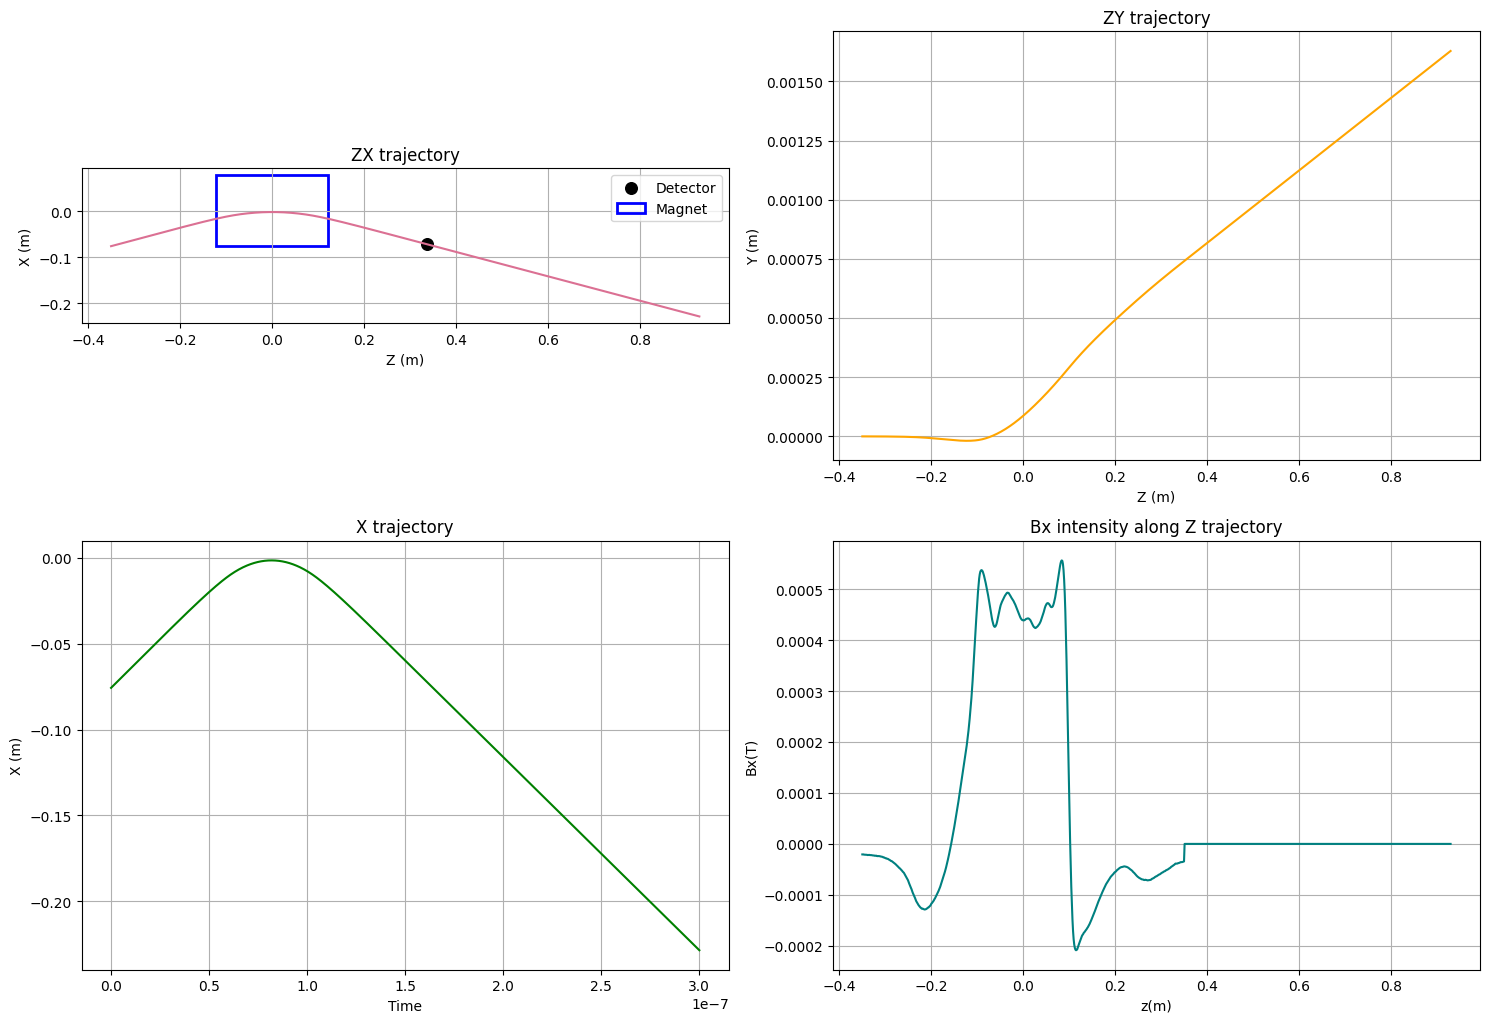

TRAJECTORY (10 A)


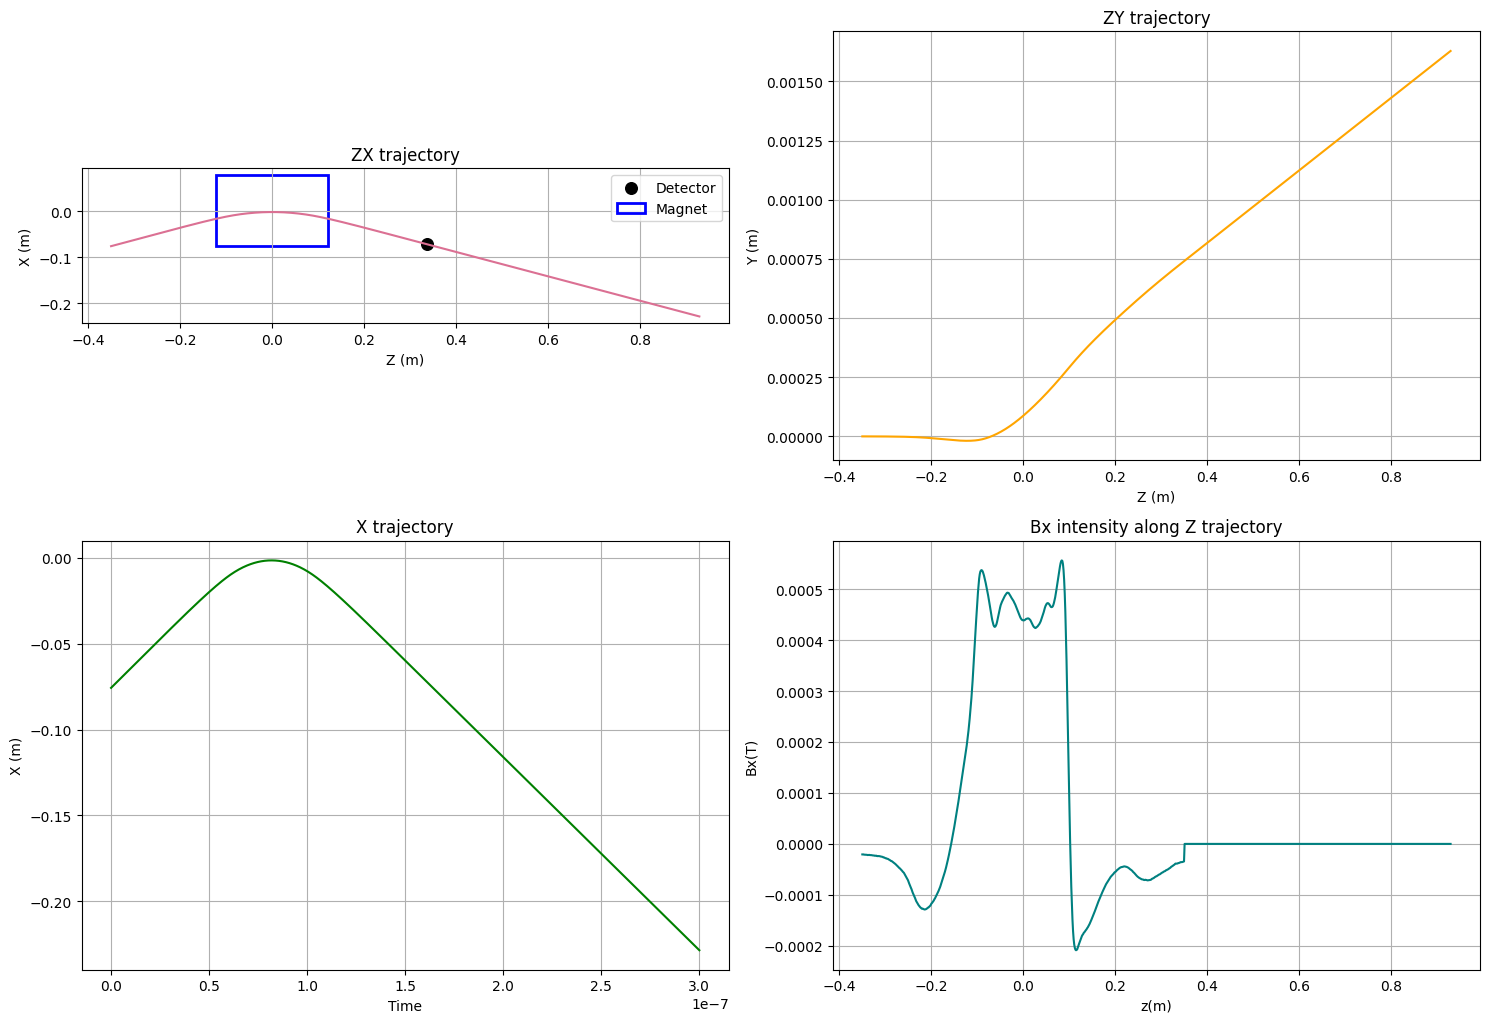

TRAJECTORY (9.95 A)


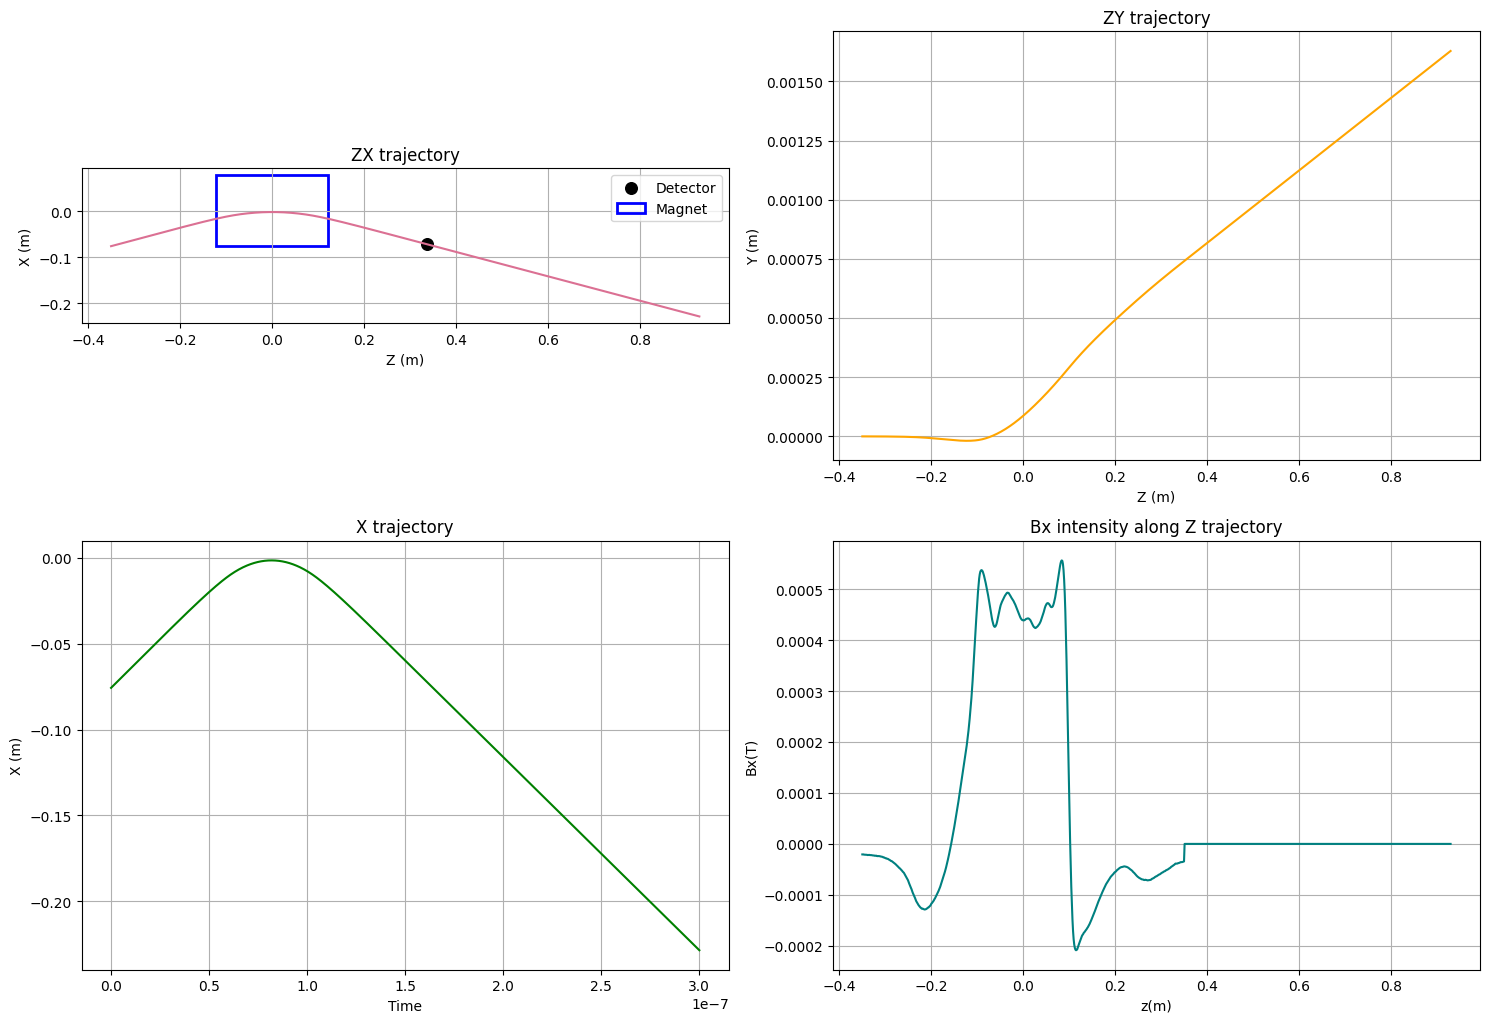

TRAJECTORY (7.5 A)


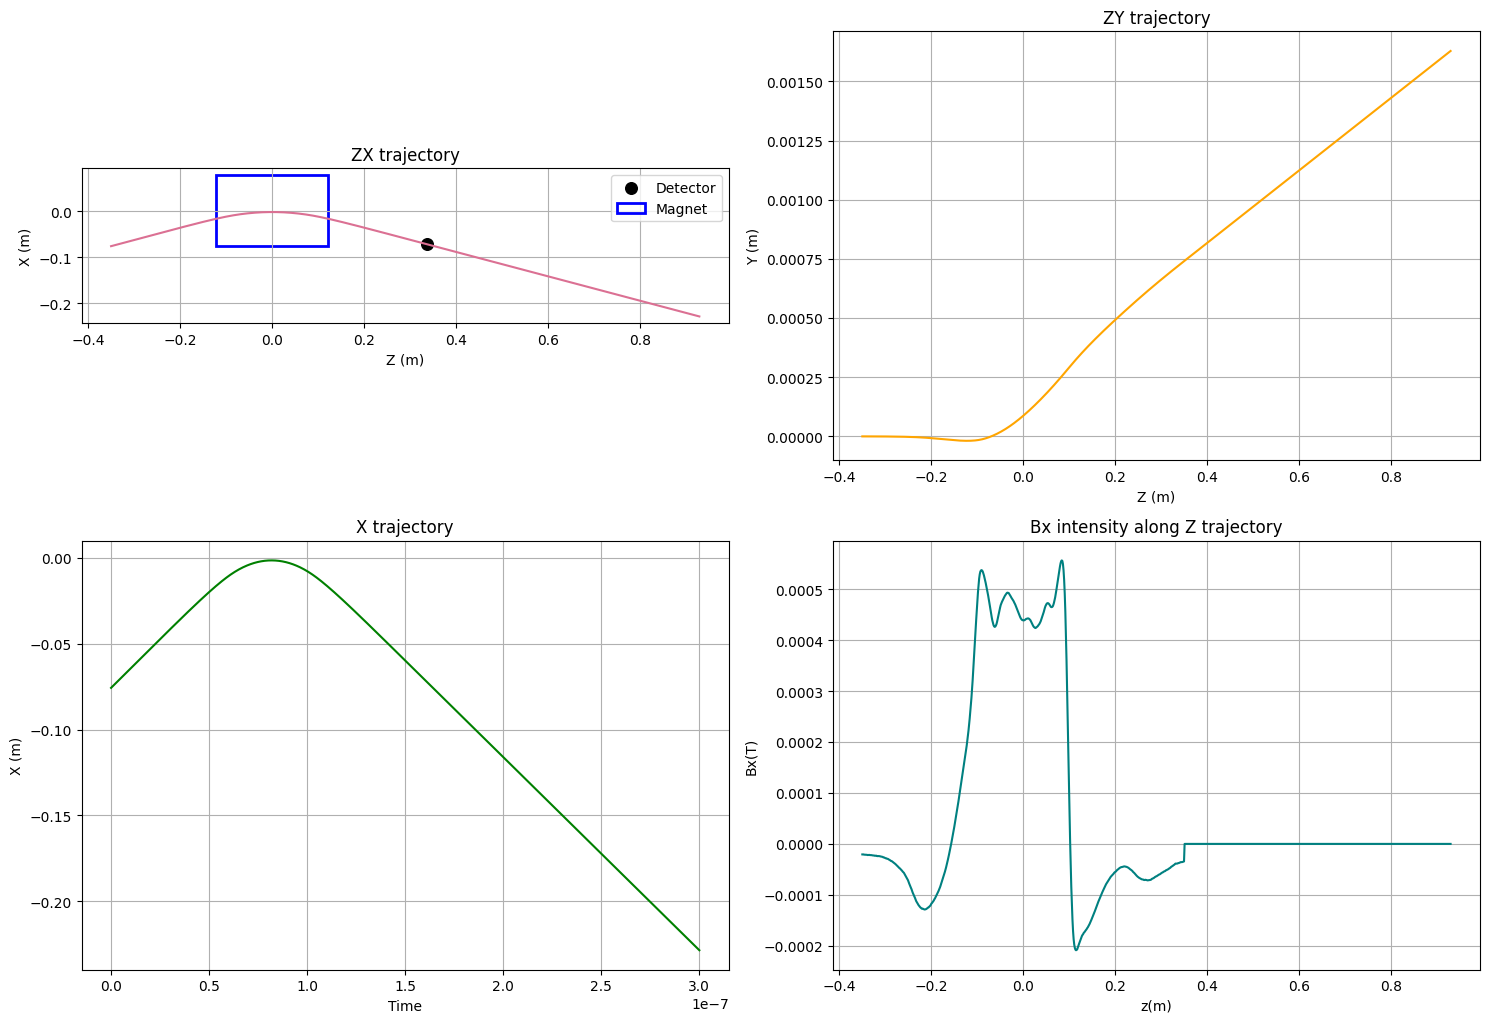

TRAJECTORY (5 A)


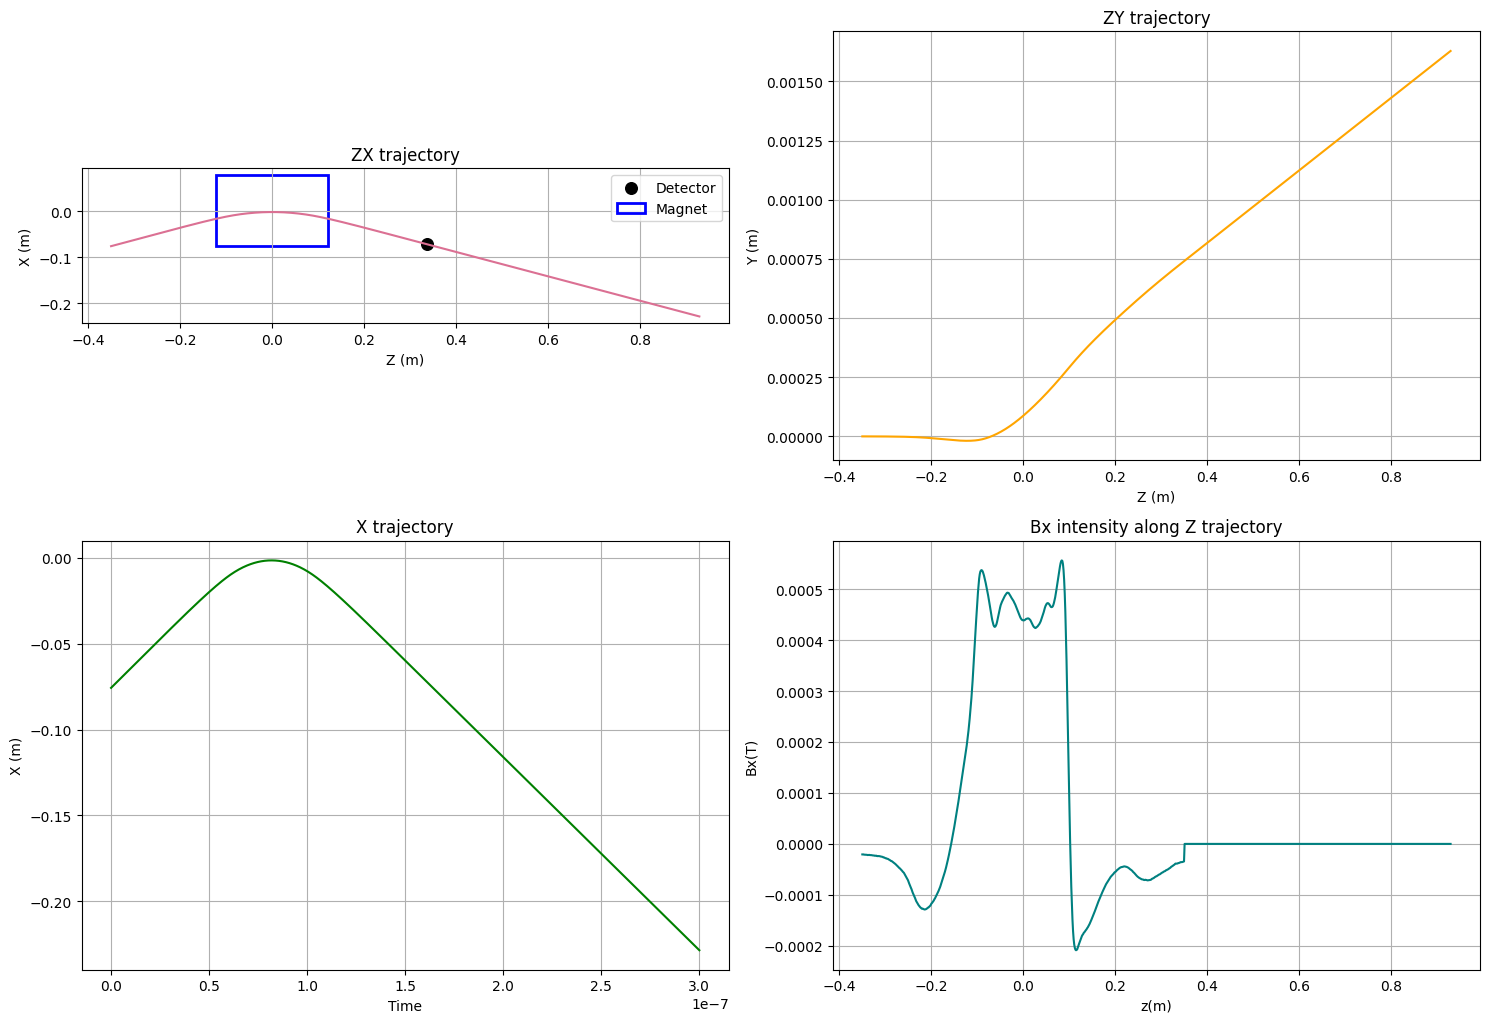

TRAJECTORY (2.5 A)


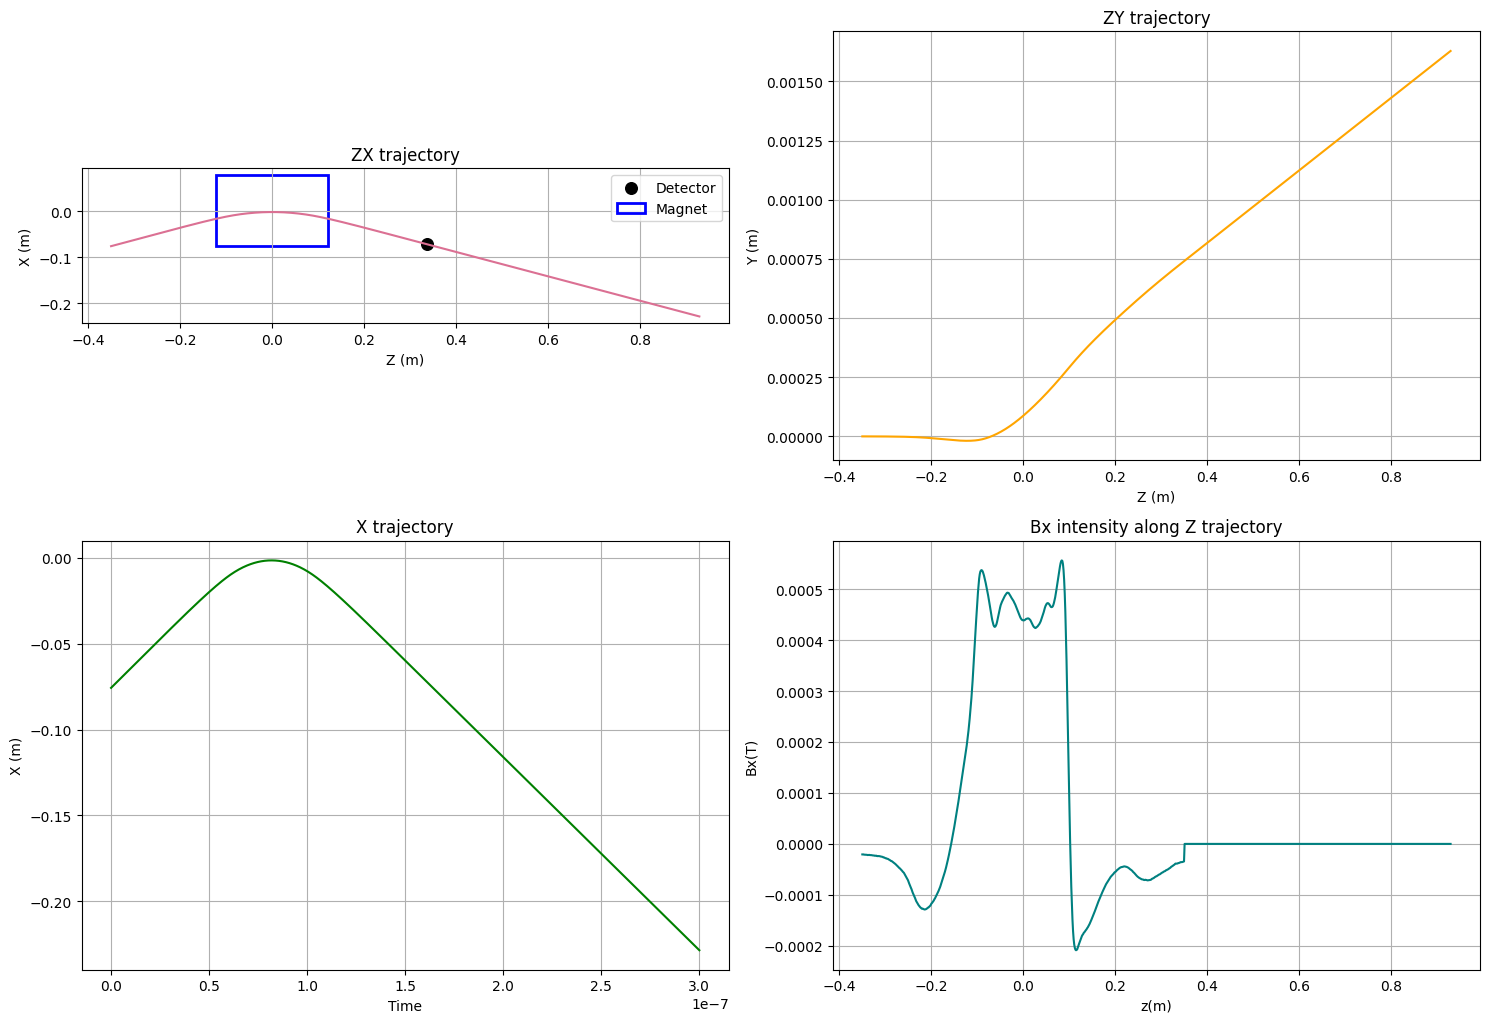

In [5]:
for file, current in zip(files, currents):
    print(f'TRAJECTORY ({current} A)')
    plot_2d_trajectory(traj, total_t, desired_x, desired_z)

### 4.2. I x E chart

In [6]:
chart.to_csv('Current_and_energy_chart.csv', sep=' ')

chart

,Current(A),Energy(MeV)
0,12.50,2.5341
1,10.00,1.6144
2,9.95,1.5346
3,7.50,0.9055
4,5.00,0.3918
5,2.50,0.1008


### 4.3. I x E graphic

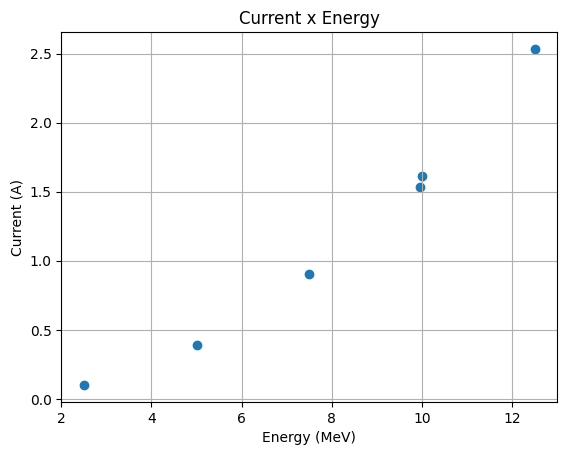

In [7]:
plt.scatter(chart['Current(A)'], chart['Energy(MeV)'])
plt.title("Current x Energy")
plt.xlabel("Energy (MeV)")
plt.ylabel("Current (A)")
plt.grid(True)
plt.show() 



### 4.4. I x E function

         2
0.01715 x - 0.01552 x + 0.03729


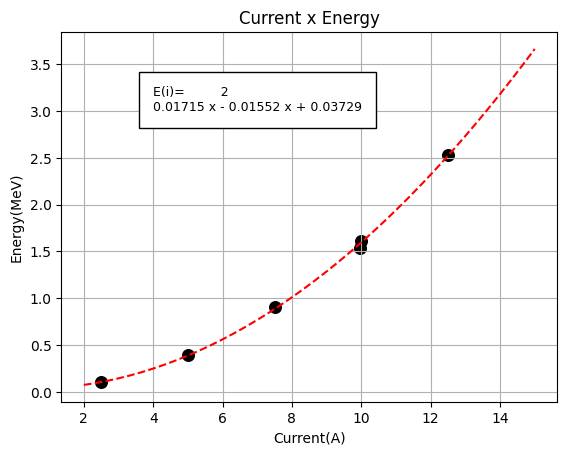

In [20]:
model01 = np.poly1d(np.polyfit(chart['Current(A)'], chart['Energy(MeV)'], 2))
plt.scatter(chart['Current(A)'], chart['Energy(MeV)'], s=70, color='k')
polyline = np.linspace(2, 15, 40)
plt.plot(polyline, model01(polyline), color='r', linestyle='--')
plt.xlabel('Current(A)')
plt.ylabel('Energy(MeV)')
plt.title('Current x Energy')
plt.grid()

plt.text(4, 3, f'E(i)={model01}', fontsize=9, color='black', bbox={'facecolor': 'white', 'pad': 10})

plt.savefig('Energy_function_of_current_graph.png', dpi=300, bbox_inches='tight')


print(model01)

        2
-1.059 x + 6.736 x + 2.142


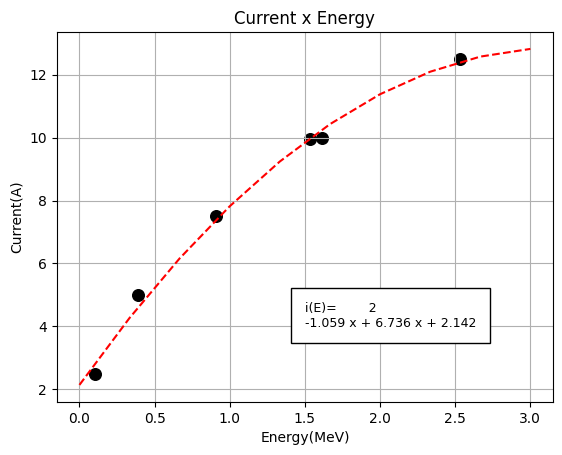

In [21]:
model02 = np.poly1d(np.polyfit(chart['Energy(MeV)'], chart['Current(A)'], 2))
plt.scatter(chart['Energy(MeV)'], chart['Current(A)'], s=70, color='k')
polyline = np.linspace(0, 3, 10)
plt.plot(polyline, model02(polyline), color='r', linestyle='--')
plt.xlabel('Energy(MeV)')
plt.ylabel('Current(A)')
plt.title('Current x Energy')
plt.grid()

plt.text(1.5, 4, f'i(E)={model02}', fontsize=9, color='black', bbox={'facecolor': 'white', 'pad': 10})

plt.savefig('Current_function_of_energy_graph.png', dpi=300, bbox_inches='tight')


print(model02)